In [1]:
ROOT = '../..' # Relative position of the root folder.

In [2]:
import sys
sys.path.append(ROOT)

In [3]:
from libs import ConfigLoader

cfgs = ConfigLoader(f'{ROOT}/configs/cfg.yaml').get_configs()
print(cfgs)

{'using_kaggle': False, 'input_folder': 'kaggle/input', 'use_dataset': 'asl-dataset', 'kaggle_override': {'input_folder': 'kaggle/input'}, 'data': {'asl-dataset': {'path': 'synthetic-asl-alphabet', 'train': 'Train_Alphabet', 'test': 'Test_Alphabet'}}}


In [4]:
from libs import ASLDataLoader

data_loader = ASLDataLoader(cfgs)
data_loader.check()

using_kaggle: False
use_dataset: asl-dataset
input_folder: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\synthetic-asl-alphabet
train_data_path: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\synthetic-asl-alphabet\Train_Alphabet
test_data_path: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\synthetic-asl-alphabet\Test_Alphabet
dataset: None
dataloader: None


In [5]:
data_loader.display_data_info(train=True)

Number of images: 24300
Number of unique classes: 27


In [6]:
data_loader.display_data_info(train=False)

Number of images: 2700
Number of unique classes: 27


In [7]:
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

In [9]:
train_dataset = data_loader.get_dataset(train=True, transform=transform)

In [10]:
import os
import random
from libs import visualize_sample_images, visualize_dataset_images, visualize_dataloader_images

Samples from Train_Alphabet


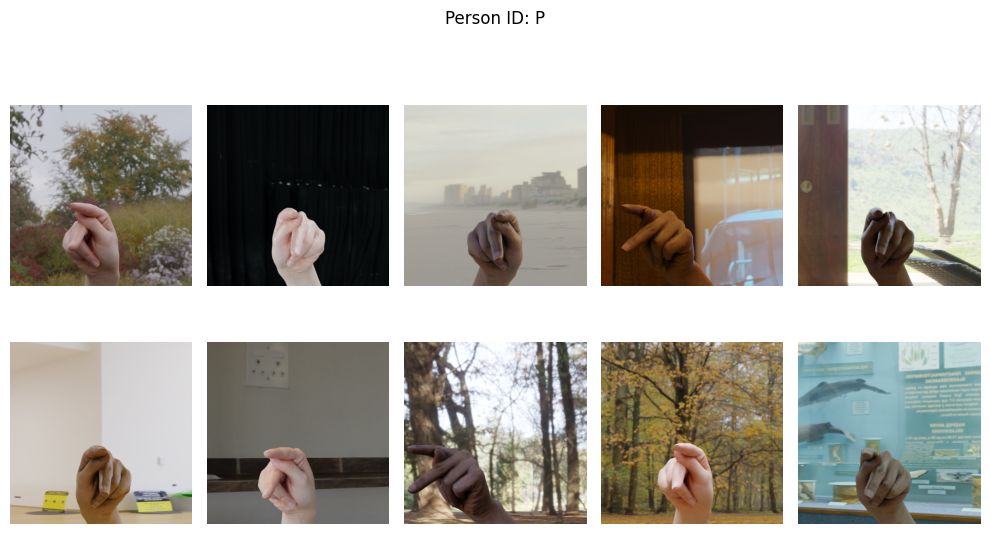

In [11]:
class_id = random.choice(os.listdir(data_loader.train_data_path))
folder_path = os.path.join(data_loader.train_data_path, class_id)
print(f'Samples from {os.path.basename(data_loader.train_data_path)}')
visualize_sample_images(folder_path)

In [12]:
train_loader = data_loader.get_dataloader(train=True, mode='standard')

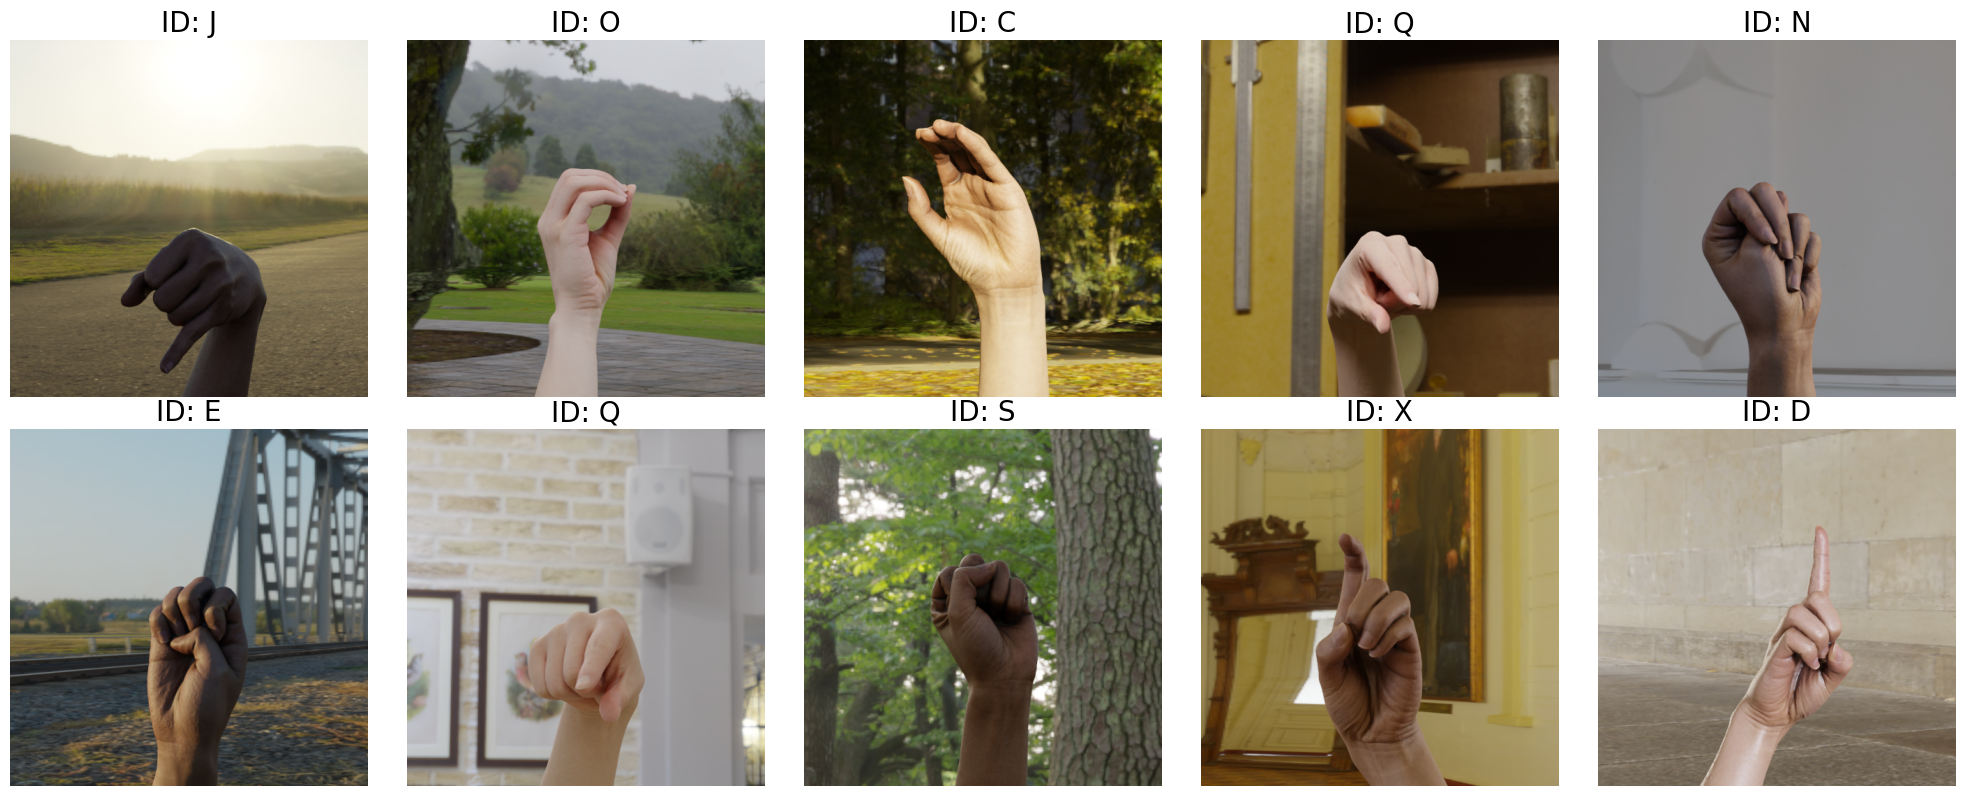

In [13]:
visualize_dataloader_images(train_loader)

In [14]:
from libs.models.efficientnet_mlp_classifier import SimpleClassifier

In [15]:
model = SimpleClassifier(num_classes=len(train_dataset.classes))

Loaded pretrained weights for efficientnet-b7
Num layers: 9


In [16]:
print(model)

SimpleClassifier(
  (model): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePa

In [17]:
import os
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.optim import Adam

In [18]:
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, device='cuda'):
    # Move model to the specified device (GPU or CPU)
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        # Iterate over the dataloader
        for inputs, _, labels in tqdm(dataloader, desc=f"Epoch {epoch + 1}"):
            # Move inputs and labels to the specified device
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()  # Clear gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Optimization step
            
            running_loss += loss.item() * inputs.size(0)  # Accumulate loss

        epoch_loss = running_loss / len(dataloader.dataset)  # Average loss for the epoch
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}')

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)
train_model(model, train_loader, criterion, optimizer, num_epochs=10)

Epoch 1: 100%|██████████| 760/760 [29:25<00:00,  2.32s/it]


Epoch 1/10, Loss: 2.4293


Epoch 2: 100%|██████████| 760/760 [28:35<00:00,  2.26s/it]


Epoch 2/10, Loss: 1.2453


Epoch 3: 100%|██████████| 760/760 [28:42<00:00,  2.27s/it]


Epoch 3/10, Loss: 0.7902


Epoch 4: 100%|██████████| 760/760 [31:31<00:00,  2.49s/it]


Epoch 4/10, Loss: 0.6096


Epoch 5:   2%|▏         | 14/760 [1:26:09<76:30:38, 369.22s/it]


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
